Until now:

- Only one face exists.

But in real systems:

- An image may contain multiple faces.
- Each face must be recognized separately.

So we must separate:

    Face Detection
    Face Recognition

### Face Detection

In [31]:
import torch
from PIL import Image, ImageDraw
from facenet_pytorch import InceptionResnetV1, MTCNN
import matplotlib.pyplot as plt

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mtcnn = MTCNN(image_size=160, margin=0, device=device, keep_all=True)
    
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

In [33]:
import os

database = {}

for person in os.listdir('faces/single'):
    for file in os.listdir(f'faces/single/{person}'):
        img = Image.open(os.path.join(f'faces/single/{person}', file))
        face = mtcnn(img)
        
        if face is None:
            continue
        
        face = face.to(device)

        with torch.no_grad():
            embedding = resnet(face)
            
        embedding = embedding / embedding.norm(dim=1, keepdim=True)
            
        database[file] = embedding
    
print(database.keys())

dict_keys(['abhishek_bachchan1.png', 'abhishek_bachchan2.png', 'abhishek_bachchan3.png', 'ab1.png', 'ab2.png', 'ab3.png', 'ab4.png', 'ab5.png', 'jaya_bachchan1.png', 'jaya_bachchan2.png', 'jaya_bachchan3.png', 'jaya_bachchan4.png', 'shail1.jpg', 'shail2.jpg'])


In [34]:
def draw_boxes(img, boxes, results):
    
    draw = ImageDraw.Draw(img)
    
    for box, (name, distance) in zip(boxes, results):
        x1, y1, x2, y2 = box
        
        color = "darkgreen" if name != "Unknown" else "red"
        
        # Draw rectangle
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        
        # Draw label text
        text = f"{name} ({distance:.2f})"
        
        draw.text((x1 - 10, y1 - 15), text, fill=color, stroke_width=0.2)
    return img

`ImageDraw.Draw(img)`

- Creates a drawing context.

`draw.rectangle([...])`

- Draws bounding box.

- Arguments:

    - [x1, y1, x2, y2]

    - outline="red" → border color

    - width=3 → thickness

`draw.text((x, y), text)`

- Writes text at position.

In [35]:
def recognize_face(query_image, database, threshold=1):
    
    img = Image.open(query_image)
    
    faces = mtcnn(img)  # detect + align + resize ALL faces
    
    if faces is None:
        return ["No Face Detected"]
    
    faces = faces.to(device)
    
    with torch.no_grad():
        embeddings = resnet(faces)  # shape: (N, 512)
        boxes, probs = mtcnn.detect(img)
    
    results = []
    
    # Loop through each detected face
    for query_embedding in embeddings:
        
        query_embedding = query_embedding.unsqueeze(0)
        
        # Normalize ONCE here
        query_embedding = query_embedding / query_embedding.norm(dim=1, keepdim=True)
        
        best_match = None
        min_distance = float('inf')
        
        for name, db_embedding in database.items():
            
            # Make sure db is normalized too
            db_embedding = db_embedding / db_embedding.norm(dim=1, keepdim=True)
            
            distance = torch.norm(query_embedding - db_embedding).item()
            
            if distance < min_distance:
                min_distance = distance
                best_match = name
            
        if min_distance < threshold:
            results.append((best_match, min_distance))
        else:
            results.append(("Unknown", min_distance))
            
        annotated = draw_boxes(img.copy(), boxes, results)
    
    return results, annotated

What is `mtcnn.detect()`?

Earlier, you used:

`face = mtcnn(img)`

That function:

- Detects the face
- Crops it
- Aligns it
- Resizes to 160×160
- Converts to tensor

It does everything automatically.

But detect() does something simpler:

> Just find where faces are.

What Does `boxes, probs = mtcnn.detect(img)` Return?

<h4>boxes</h4>

Shape:

`(N, 4)`

Each box:

`[x1, y1, x2, y2]`

Meaning:

- Top-left corner (x1, y1)
- Bottom-right corner (x2, y2)

Coordinates are pixel positions in the original image.

If 3 faces are found:

    boxes = [
        [50, 40, 150, 140],
        [200, 60, 310, 180],
        [350, 45, 460, 170]
    ]
    
<h4>probs</h4>

Confidence score for each detection.

Range:

`0 to 1`

Closer to 1 = very confident it's a face.

We ignore it for now, but later we can filter low-confidence detections.

In [36]:
results, annotated = recognize_face("faces/multiple/ab_family_photo1.png", database)

print("Results: ", results)

Results:  [('abhishek_bachchan3.png', 0.6610929369926453), ('jaya_bachchan1.png', 0.7809887528419495), ('ab3.png', 0.6771852970123291), ('Unknown', 1.1926240921020508), ('Unknown', 1.2480425834655762)]


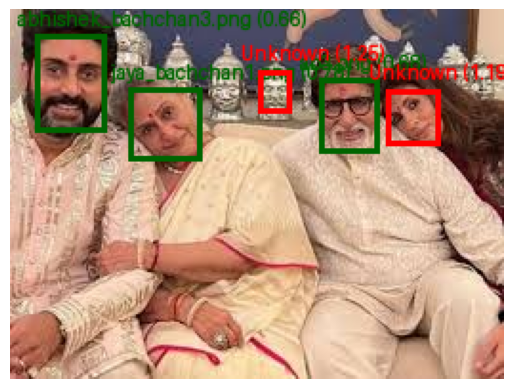

Found Face: abhishek_bachchan3.png
Distance: 0.6610929369926453


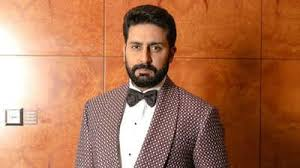

Found Face: jaya_bachchan1.png
Distance: 0.7809887528419495


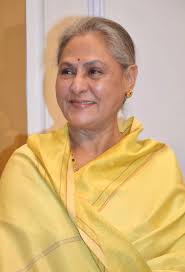

Found Face: ab3.png
Distance: 0.6771852970123291


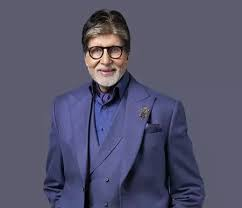

In [46]:
plt.imshow(annotated)
plt.axis('off')
plt.show()

for result in results:
    
    if(result[0] == 'Unknown'):
        continue
            
    for person in os.listdir('faces/single'):
        for face in os.listdir(f'faces/single/{person}'):                
            
            if result[0] != face:
                continue
            
            img = Image.open(f'faces/single/{person}/{result[0]}')
            print(f"Found Face: {result[0]}")
            print(f"Distance: {result[1]}")
            display(img)